In [2]:
import os

# Update these paths to where your folder is located
sdd1_path = "./AL1_SLX_L1_20260617_v1.0/sdd1"
sdd2_path = "./AL1_SLX_L1_20260617_v1.0/sdd2"

print("Files in SDD1:", os.listdir(sdd1_path)[:5]) # Shows first 5 files
print("Files in SDD2:", os.listdir(sdd2_path)[:5])

Files in SDD1: ['AL1_SOLEXS_20260617_SDD1_L1.gti.gz']
Files in SDD2: ['AL1_SOLEXS_20260617_SDD2_L1.gti.gz', 'AL1_SOLEXS_20260617_SDD2_L1.lc.gz', 'AL1_SOLEXS_20260617_SDD2_L1.pi.gz']


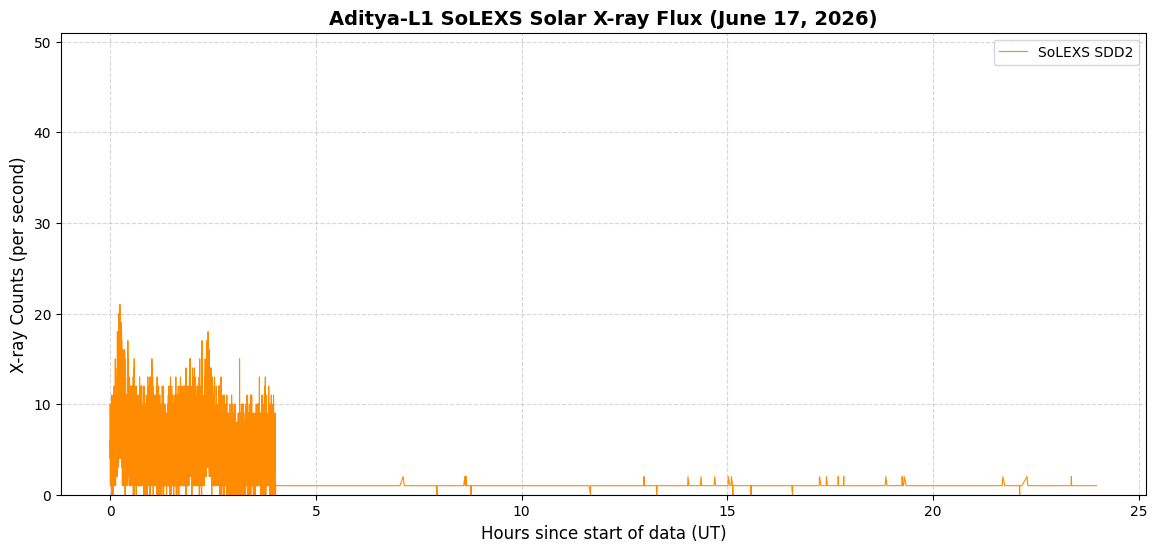

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

lc_file_path = './AL1_SLX_L1_20260617_v1.0/sdd2/AL1_SOLEXS_20260617_SDD2_L1.lc.gz'

with fits.open(lc_file_path) as hdul:
    data_table = hdul[1].data

    # --- THE ABSOLUTE FIX ---
    # .astype(float) forces numpy to write a brand new array natively
    # matching your system's little-endian architecture.
    data_dict = {
        'TIME': np.array(data_table['TIME']).astype(float),
        'COUNTS': np.array(data_table['COUNTS']).astype(float)
    }
    df = pd.DataFrame(data_dict)

# 1. Clean the data: Drop rows where COUNTS is NaN (Will work beautifully now!)
df = df.dropna(subset=['COUNTS'])

# 2. Convert Instrument Time to hours relative to the start of the data
df['RELATIVE_TIME_HR'] = (df['TIME'] - df['TIME'].min()) / 3600.0

# 3. Plotting the Light Curve
plt.figure(figsize=(14, 6))
plt.plot(df['RELATIVE_TIME_HR'], df['COUNTS'], color='darkorange', lw=0.8, label='SoLEXS SDD2')

plt.title('Aditya-L1 SoLEXS Solar X-ray Flux (June 17, 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Hours since start of data (UT)', fontsize=12)
plt.ylabel('X-ray Counts (per second)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Limit y-axis dynamically to filter out rogue high-energy noise spikes
plt.ylim(0, df['COUNTS'].quantile(0.999) * 3)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
from astropy.io import fits

def process_solexs_file(file_path):
    # Load FITS data safely for NumPy 2.0+
    with fits.open(file_path) as hdul:
        data_table = hdul[1].data
        data_dict = {
            'TIME': np.array(data_table['TIME']).astype(float),
            'COUNTS': np.array(data_table['COUNTS']).astype(float)
        }
        df = pd.DataFrame(data_dict)

    # Step A: Drop NaN values
    df = df.dropna(subset=['COUNTS'])

    # Step B: Filter out Telemetry Dead Zones / Standby Modes
    # Real data has continuous natural variance; the artifact flatline is fixed precisely at 1.0.
    df = df[df['COUNTS'] > 1.1]

    # Step C: Smooth out high-frequency cosmic noise spikes
    # Using a 10-second rolling median preserves flare edges while removing pixel noise
    df['SMOOTH_COUNTS'] = df['COUNTS'].rolling(window=10, center=True).median()
    df = df.dropna()

    # Step D: Feature Engineering for Flare Prediction
    # ML models predict flares based on looking backward at historical context windows.
    df['ROLLING_MEAN_1M'] = df['SMOOTH_COUNTS'].rolling(window=60).mean()   # Last 1 min avg
    df['ROLLING_MEAN_5M'] = df['SMOOTH_COUNTS'].rolling(window=300).mean()  # Last 5 min avg

    # Gradient (Rate of change): The ultimate telltale sign of an impending flare
    df['DERIVATIVE_10S'] = df['SMOOTH_COUNTS'].diff(periods=10)

    return df.dropna()

# Convert your file into a clean, feature-rich DataFrame
clean_df = process_solexs_file('./AL1_SLX_L1_20260617_v1.0/sdd2/AL1_SOLEXS_20260617_SDD2_L1.lc.gz')
print(clean_df[['TIME', 'COUNTS', 'ROLLING_MEAN_5M', 'DERIVATIVE_10S']].head())

             TIME  COUNTS  ROLLING_MEAN_5M  DERIVATIVE_10S
325  1.781655e+09     7.0         4.766667             2.0
326  1.781655e+09     7.0         4.766667             1.5
327  1.781655e+09     6.0         4.768333             1.0
328  1.781655e+09     3.0         4.771667             0.0
329  1.781655e+09     7.0         4.775000             0.0
